In [1]:
import pandas as pd
import numpy as np
import sklearn.manifold
from scipy.spatial.distance import cosine
from scipy.stats import entropy
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import normalize
from sklearn.manifold import TSNE
import seaborn as sns
import umap
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
import hdbscan
from sklearn.metrics.pairwise import cosine_distances
from scipy.stats import pearsonr
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import glm
import matplotlib.colors as mcolors
from stargazer.stargazer import Stargazer
from IPython.display import HTML, display

# Set colorblind-friendly palette globally
sns.set_palette('colorblind')
plt.rcParams['figure.facecolor'] = 'white'


/Users/sarawu/Git_Projects/idea_generation/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

## Clustering
# 1. Load data
file_path = '../../data/iriss_manual_ratings_metrics.csv' 
df = pd.read_csv(file_path)

# 2. Initialize Model
model = SentenceTransformer('all-MiniLM-L6-v2')

# 3. Generate Embeddings
ideas = df['use'].fillna("").tolist()
ideas = [idea.strip().lower() for idea in ideas]
all_embeddings = model.encode(ideas, show_progress_bar=True)

pd.DataFrame(all_embeddings)


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2383.98it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 67/67 [00:01<00:00, 57.40it/s]


,0,1,2,3,4,5,6,7,8,9,...,374,375,376,377,378,379,380,381,382,383
0,-0.079065,-0.026878,0.015101,-0.034421,0.040105,-0.038276,0.007938,0.034960,-0.050222,0.017058,...,0.001765,-0.016393,-0.010718,0.040712,0.004646,0.013427,0.070290,-0.156736,0.022741,0.034727
1,0.004457,0.058288,-0.028428,0.016799,-0.079709,-0.001911,0.126785,0.016692,0.066231,0.036961,...,0.001356,0.076891,0.032260,0.022076,-0.068987,0.071251,0.050479,0.082349,-0.000656,0.019747
2,-0.088395,-0.032277,0.072302,0.028733,0.009583,-0.040250,0.055280,0.081512,-0.000041,-0.072588,...,0.047585,-0.004435,-0.011425,-0.019062,0.042426,-0.005644,-0.014787,0.058003,0.116100,0.022069
3,0.027765,0.067004,0.010543,-0.016163,-0.027840,0.006665,0.051340,0.030578,0.048688,-0.038817,...,0.036175,0.043070,0.037453,-0.013052,-0.027943,-0.074494,0.000954,0.015982,0.075768,0.013063
4,-0.022940,0.099445,0.033540,0.038258,-0.060314,0.002718,0.042374,-0.056076,0.068843,0.015437,...,-0.024890,-0.010946,0.054169,0.059746,0.082738,0.028220,0.080960,-0.028201,0.040589,-0.007083
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2125,-0.008938,0.086135,-0.047358,0.047561,-0.087495,-0.025190,0.039952,-0.058201,0.057946,0.013241,...,-0.026982,-0.011407,0.036515,0.014895,-0.028532,0.008726,0.005076,0.066527,0.099203,-0.034642
2126,0.039300,0.178547,0.023723,0.036835,0.009545,-0.035941,0.056137,-0.004402,-0.002404,0.033109,...,-0.022326,-0.031124,0.000801,-0.026975,-0.012295,0.010361,0.047977,-0.104348,0.001861,0.052343
2127,-0.065410,0.126963,-0.022973,-0.030144,0.001417,0.004159,0.159206,-0.015415,-0.039364,0.017834,...,-0.007818,0.004923,0.067541,0.041299,0.029551,0.001430,-0.032418,-0.012276,0.032985,-0.006903
2128,-0.069323,0.065580,0.069012,0.098720,0.049162,0.001549,0.089048,0.025077,-0.099772,-0.080223,...,0.017511,0.042079,-0.055730,0.024963,0.003469,-0.001499,0.058570,-0.034315,0.019789,0.050130


In [13]:
# 4. Prepare for Clustering
unique_objects = df['object'].unique()
unique_conditions = df['condition'].unique()

def cluster_ideas(min_cluster_size, min_samples, cluster_selection_epsilon):
    labels = pd.Series(-1, index=df.index, dtype=int)

    for condition in unique_conditions:
        for obj in unique_objects:
            mask = (df['object'] == obj) & (df['condition'] == condition)
            vectors = normalize(all_embeddings[mask])
            if len(vectors) < min_cluster_size:
                continue

            clusterer = hdbscan.HDBSCAN(
                min_cluster_size=min_cluster_size,
                min_samples=min_samples,
                cluster_selection_epsilon=float(cluster_selection_epsilon),
                metric='euclidean',
                cluster_selection_method='eom'
            )
            labels.loc[mask] = clusterer.fit_predict(vectors)

    return labels

# Original clustering result, using min_cluster_size=6
df['raw_cluster_label'] = cluster_ideas(6, 1, 0.25)
pd.DataFrame(df)

,rater_id,stimulus,object,submitter_id,condition,use,use_word_count,trial,creativity,originality,usefulness,raw_cluster_label,largest_cluster
0,R_38iagc8h6FJRgGt,frisbee_1,frisbee,R_6PaRsYR92IuSbQL,Low-Agency,new shoe trend,3,frisbee_1,2,3,1,0,NaN
1,R_38iagc8h6FJRgGt,frisbee_2,frisbee,R_3xr2GhF3M02FlIZ,High-Agency,seat,1,frisbee_2,2,2,2,-1,NaN
2,R_38iagc8h6FJRgGt,frisbee_3,frisbee,R_6ydDuphsh56INel,Control,to make slime in,4,frisbee_3,1,1,2,-1,NaN
3,R_38iagc8h6FJRgGt,frisbee_4,frisbee,R_7J8gOu2FCCC6mQh,Control,Pot base,2,frisbee_4,2,2,3,8,True
4,R_38iagc8h6FJRgGt,frisbee_5,frisbee,R_7d1ftMosPxb6Ztd,Control,Wreath,1,frisbee_5,3,4,3,6,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2125,R_34BrAilVWsYXow9,bubblewrap_1,bubblewrap,R_7OQcdAu9RD1dnvH,High-Agency,To use as a pillow,5,bubblewrap_1,3,4,4,7,NaN
2126,R_34BrAilVWsYXow9,bubblewrap_2,bubblewrap,R_3I9NjNzA56uNz0C,Control,As a Christmas tree skirt,5,bubblewrap_2,1,1,1,-1,NaN
2127,R_34BrAilVWsYXow9,bubblewrap_3,bubblewrap,R_6pScTLMYRvoFZfX,High-Agency,use for costume,3,bubblewrap_3,2,2,3,1,NaN
2128,R_34BrAilVWsYXow9,bubblewrap_4,bubblewrap,R_1jKUeVXkROyxlh7,High-Agency,DIY stress relief,3,bubblewrap_4,2,3,4,8,NaN


In [4]:
# Focus on the largest cluster for each object-condition pair
# Ignore noise points (label -1) and find the largest cluster
for cond in unique_conditions:
    for obj in unique_objects:
        obj_cond_mask = (df['object'] == obj) & (df['condition'] == cond)
        cluster_labels = df.loc[obj_cond_mask, 'raw_cluster_label']
        
        # Count occurrences of each cluster label
        cluster_counts = cluster_labels.value_counts()
        
        # Ignore noise points (-1)
        cluster_counts = cluster_counts[cluster_counts.index != -1]
        
        if not cluster_counts.empty:
            largest_cluster_label = cluster_counts.idxmax()
            df.loc[obj_cond_mask & (df['raw_cluster_label'] == largest_cluster_label), 'largest_cluster'] = True
        else:
            df.loc[obj_cond_mask, 'largest_cluster'] = False

# Display representative examples from the largest clusters
for cond in unique_conditions:
    for obj in unique_objects:
        largest_cluster_mask = (df['object'] == obj) & (df['condition'] == cond) & (df['largest_cluster'] == True)
        representative_ideas = df.loc[largest_cluster_mask, 'use'].sample(n=min(10, largest_cluster_mask.sum()), random_state=42).tolist()
        
        print(f"Condition: {cond}, Object: {obj}")
        print("Representative Ideas from Largest Cluster:")
        for idea in representative_ideas:
            print(f"- {idea}")
        print("\n")

Condition: Low-Agency, Object: frisbee
Representative Ideas from Largest Cluster:
- paint plate
- snack trays
- A plate for food, seems like a great plate for young kids bc it wont break
- Plate
- Plates or trays
- a plate
- A plate for food, seems like a great plate for young kids bc it wont break
- Plates or trays
- plate
- dinner plate


Condition: Low-Agency, Object: brick
Representative Ideas from Largest Cluster:
- Water Filtration: Use a brick as part of a makeshift water filtration system by layering it with sand, gravel, and cloth to filter out debris and impurities.
- Brick to create furniture
- grind it down and make it into a paste that can be used as concrete to them rebuild the same building that was made from bricks
- outdoor fire pit
- Use a brick as a doorstop by wrapping it in decorative fabric or painting it with fun patterns.
- Show me a image set of example of a brick
- Brick Mosaic Art
- Broken brick pieces in mosaic art.
- gluing them together to create a shelf
-

In [5]:

# Get noise ratios for each condition and object
noise_ratios = df.groupby(['condition', 'object'])['raw_cluster_label'].apply(lambda x: (x == -1).mean())
print("Noise Ratios by Condition and Object:")
print(noise_ratios)

# Number of clusters per condition and object (excluding noise)
num_clusters = df[df['raw_cluster_label'] != -1].groupby(['condition', 'object'])['raw_cluster_label'].nunique()
print("\nNumber of Clusters by Condition and Object (excluding noise):")
print(num_clusters)

# Coefficient of variation for cluster sizes (excluding noise)
def coefficient_of_variation(counts):
    if len(counts) == 0:
        return np.nan
    return np.std(counts) / np.mean(counts)
cv_values = df[df['raw_cluster_label'] != -1].groupby(['condition', 'object'])['raw_cluster_label'].apply(lambda x: coefficient_of_variation(x.value_counts()))
print("\nCoefficient of Variation for Cluster Sizes by Condition and Object:")
print(cv_values)

# Get mean and standard deviation for unique clusters, noise ratio, and CV by condition
unique_counts = (
    df[df['raw_cluster_label'] != -1]
    .groupby(['condition', 'object'])['raw_cluster_label']
    .nunique()
    .reset_index(name='n_unique_clusters')
)

cluster_stats = (
    unique_counts
    .groupby('condition')['n_unique_clusters']
    .agg(['mean', 'std'])
    .reset_index()
)

# Add noise ratio and CV to the stats
condition_summaries = pd.concat(
    [
        noise_ratios.groupby(level='condition').agg(['mean', 'std']).rename(
            columns={'mean': 'noise_ratio', 'std': 'noise_ratio_sd'}
        ),
        cv_values.groupby(level='condition').agg(['mean', 'std']).rename(
            columns={'mean': 'cv', 'std': 'cv_sd'}
        ),
    ],
    axis=1
).reset_index()

# Unique-cluster stats + merge in noise/CV stats
cluster_stats = (
    unique_counts
    .groupby('condition', as_index=False)['n_unique_clusters']
    .agg(mean='mean', std='std')
    .merge(condition_summaries, on='condition', how='left')
)

# Display the statistics
print("\nCluster Statistics by Condition:")
print(cluster_stats)

Noise Ratios by Condition and Object:
condition    object    
Control      brick         0.512712
             bubblewrap    0.455598
             frisbee       0.421277
High-Agency  brick         0.426230
             bubblewrap    0.324895
             frisbee       0.451477
Low-Agency   brick         0.330435
             bubblewrap    0.467290
             frisbee       0.512605
Name: raw_cluster_label, dtype: float64

Number of Clusters by Condition and Object (excluding noise):
condition    object    
Control      brick         10
             bubblewrap    14
             frisbee       13
High-Agency  brick         13
             bubblewrap    10
             frisbee       14
Low-Agency   brick          7
             bubblewrap     5
             frisbee       13
Name: raw_cluster_label, dtype: int64

Coefficient of Variation for Cluster Sizes by Condition and Object:
condition    object    
Control      brick         0.377536
             bubblewrap    0.315025
             f

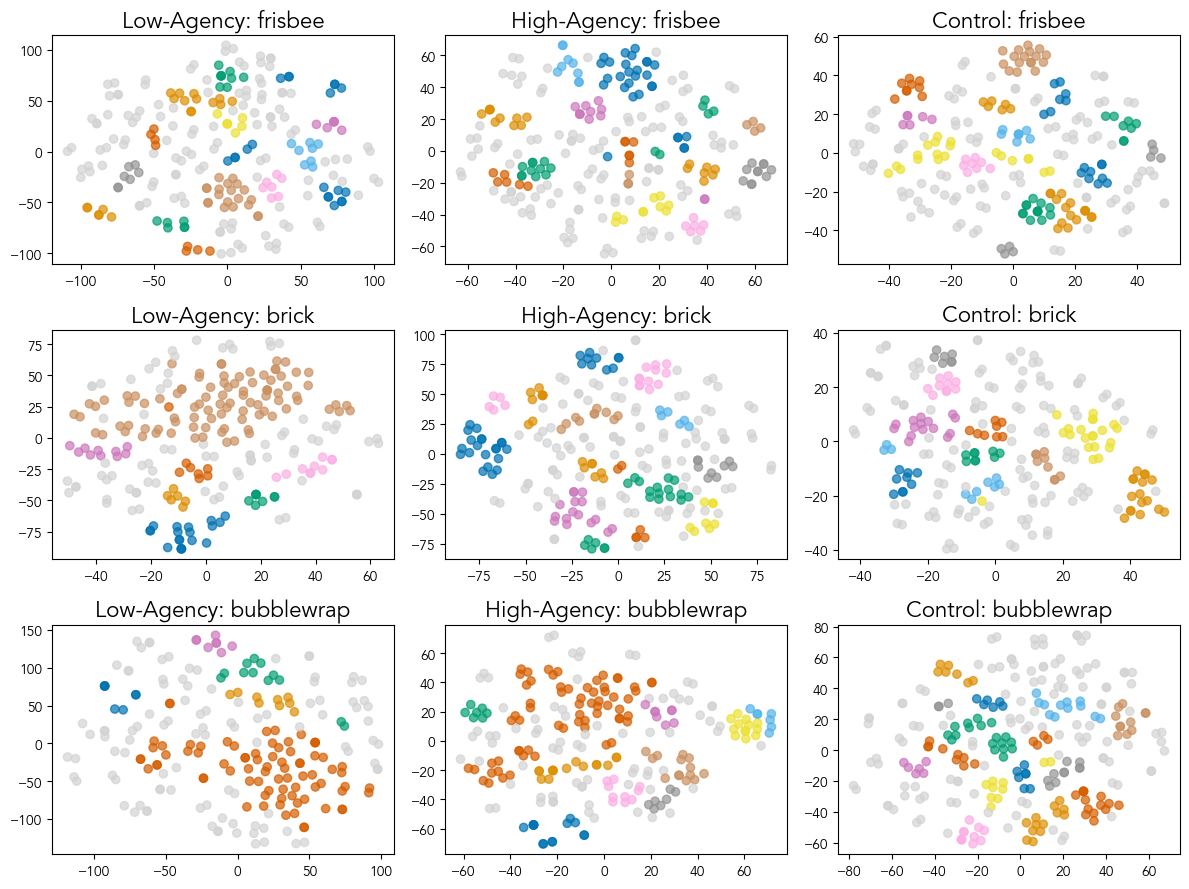

In [6]:
# Repeat for all object-condition pairs and display the results in a grid of t-SNE plots

n_objects = len(unique_objects)
n_conditions = len(unique_conditions)
condition_order = ['Low-Agency', 'High-Agency', 'Control']

# Use Avenir font for better aesthetics
plt.rcParams['font.family'] = 'Avenir'

# Increase the text size of the titles
plt.rcParams['axes.titlesize'] = 16

# Create a grid of subplots
fig, axes = plt.subplots(n_objects, n_conditions, figsize=(4*n_conditions, 3*n_objects), squeeze=False)

# For each object-condition pair, plot t-SNE
for i, obj in enumerate(unique_objects):
    for j, condition in enumerate(condition_order):
        obj_cond_mask = (df['object'] == obj) & (df['condition'] == condition)
        if obj_cond_mask.sum() < 2:  # Skip if less than 2 samples
            ax = axes[i][j]
            ax.text(0.5, 0.5, "Not enough samples", ha='center', va='center', transform=ax.transAxes)
            continue

        data = all_embeddings[obj_cond_mask]
        projection = sklearn.manifold.TSNE().fit_transform(data)

        # Color the points by their cluster labels to visually inspect the clustering quality
        labels = df.loc[obj_cond_mask, 'raw_cluster_label'].values
        unique_labels = np.sort(np.unique(labels))

        # Build color map where -1 is light gray using colorblind-friendly palette
        base_colors = sns.color_palette('colorblind', n_colors=max(len(unique_labels), 1))
        color_map = {}
        color_iter = iter(base_colors)

        for lab in unique_labels:
            if lab == -1:
                color_map[lab] = 'lightgray'
            else:
                color_map[lab] = next(color_iter, 'black')

        cmap = mcolors.ListedColormap([color_map[lab] for lab in unique_labels])
        norm = mcolors.BoundaryNorm(np.append(unique_labels, unique_labels[-1] + 1), cmap.N)

        axes[i][j].scatter(projection[:, 0], projection[:, 1], c=labels, cmap=cmap, norm=norm, alpha=0.7)
        axes[i][j].set_title(f"{condition}: {obj}")
        
        
plt.tight_layout()
plt.show()

# Save a high-resolution version of the plot
fig.savefig('tsne_clusters.png', dpi=300)


### Robustness Sweep

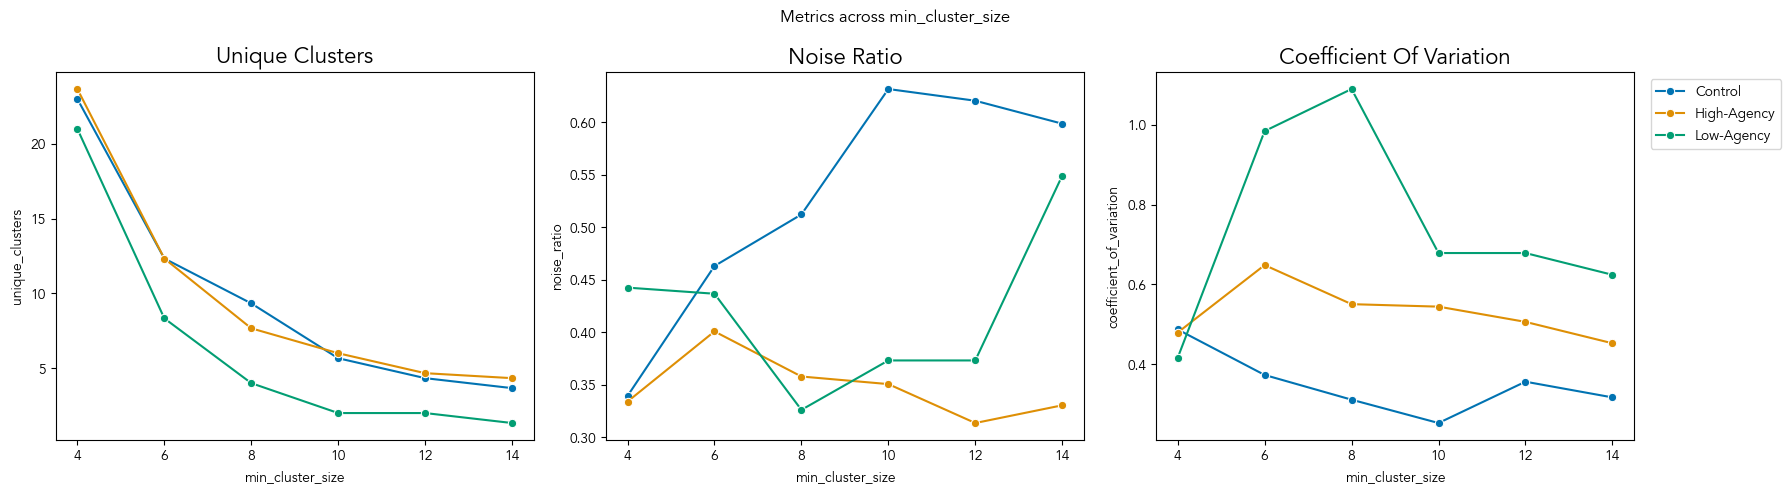

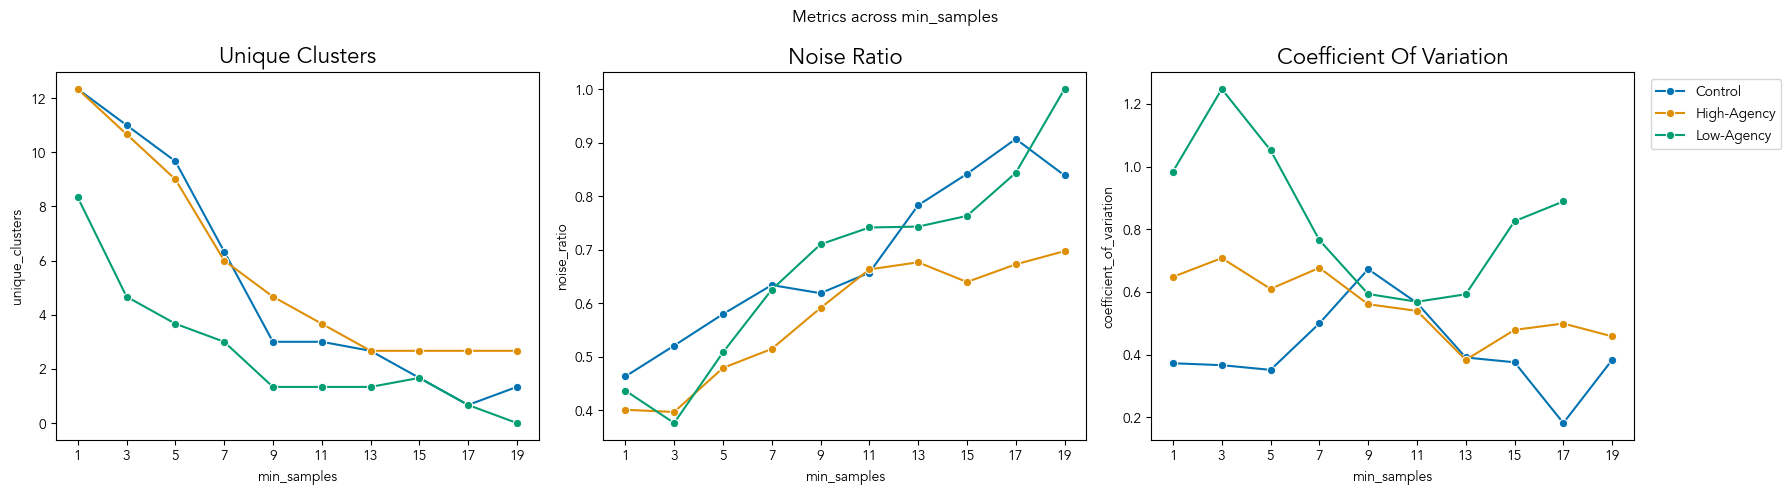

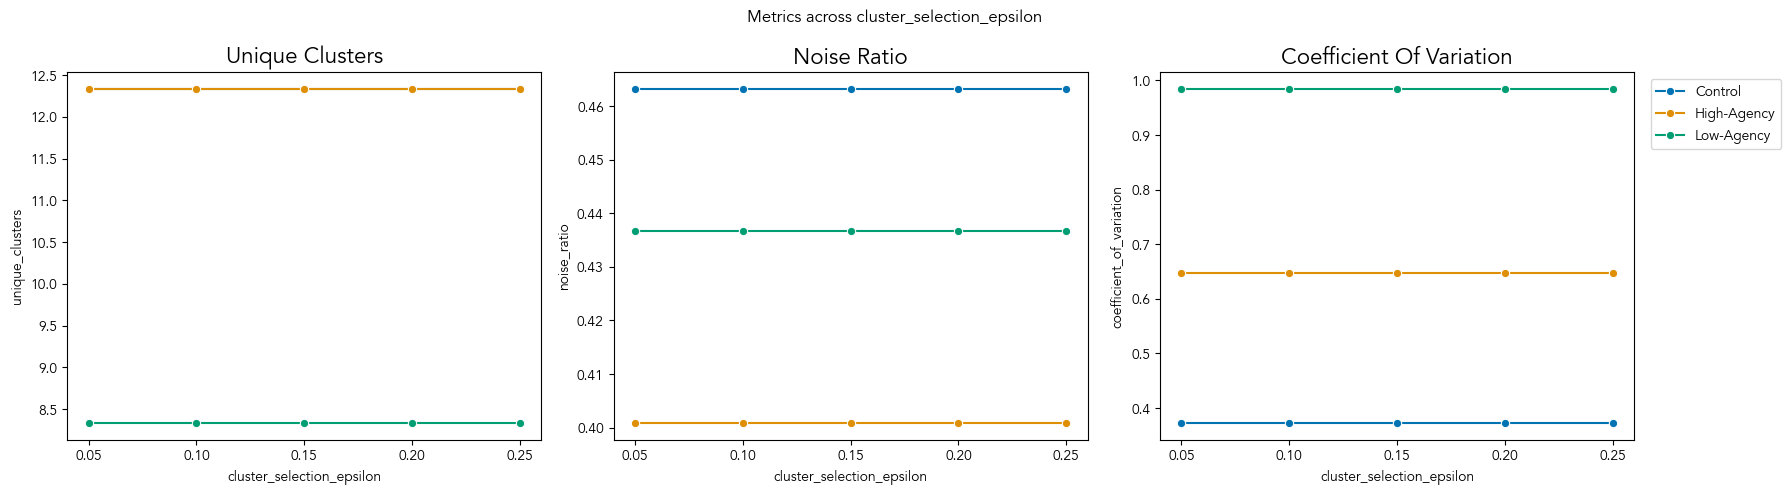

,cluster_selection_epsilon,condition,unique_clusters,noise_ratio,coefficient_of_variation
0,0.05,Control,12.333333,0.463196,0.372587
1,0.05,High-Agency,12.333333,0.400867,0.648218
2,0.05,Low-Agency,8.333333,0.436777,0.984353
3,0.10,Control,12.333333,0.463196,0.372587
4,0.10,High-Agency,12.333333,0.400867,0.648218
5,0.10,Low-Agency,8.333333,0.436777,0.984353
6,0.15,Control,12.333333,0.463196,0.372587
7,0.15,High-Agency,12.333333,0.400867,0.648218
8,0.15,Low-Agency,8.333333,0.436777,0.984353
9,0.20,Control,12.333333,0.463196,0.372587


In [ ]:
def cluster_metrics(labels):
    rows = []
    for condition in unique_conditions:
        for obj in unique_objects:
            mask = (df['condition'] == condition) & (df['object'] == obj)
            counts = labels[mask].loc[lambda x: x != -1].value_counts()
            rows.append({
                'condition': condition,
                'object': obj,
                'unique_clusters': len(counts),
                'noise_ratio': (labels[mask] == -1).mean(),
                'coefficient_of_variation': coefficient_of_variation(counts)
            })
    return pd.DataFrame(rows)

min_cluster_sizes = range(4, 16, 2)
min_samples_values = range(1, 20, 2)
epsilon_values = np.arange(0.05, 0.26, 0.05)

sweep_results = pd.concat([
    cluster_metrics(
        cluster_ideas(size, min_samples, epsilon)
    ).assign(
        min_cluster_size=size,
        min_samples=min_samples,
        cluster_selection_epsilon=epsilon
    )
    for size in min_cluster_sizes
    for min_samples in min_samples_values
    for epsilon in epsilon_values
], ignore_index=True)
sweep_results.to_csv('../../data/hdbscan_parameter_sweep.csv', index=False)

metric_names = ['unique_clusters', 'noise_ratio', 'coefficient_of_variation']

def plot_metric_sweep(data, x, title):
    results = data.groupby([x, 'condition'], as_index=False)[metric_names].mean()
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    palette = {
        'Control': '#f7e96f',
        'High-Agency': '#71b79f',
        'Low-Agency': '#3a144e'
    }
    for ax, metric in zip(axes, metric_names):
        sns.lineplot(
            data=results,
            x=x, y=metric, hue='condition', marker='o', ax=ax
        )
        # Manually set the colors for each condition using the hex codes
        for line, condition in zip(ax.lines, condition_order):
            line.set_color(palette.get(condition, 'black'))
        ax.set_title(metric.replace('_', ' ').title())
        ax.set_xlabel(x)
        ax.set_xticks(sorted(data[x].unique()))
        ax.legend_.remove()

    axes[-1].legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()
    return results

plot_metric_sweep(
    sweep_results[
        (sweep_results['min_samples'] == 1) &
        (sweep_results['cluster_selection_epsilon'] == 0.25)
    ],
    'min_cluster_size',
    'Metrics across min_cluster_size'
)

plot_metric_sweep(
    sweep_results[
        (sweep_results['min_cluster_size'] == 6) &
        (sweep_results['cluster_selection_epsilon'] == 0.25)
    ],
    'min_samples',
    'Metrics across min_samples'
)

plot_metric_sweep(
    sweep_results[
        (sweep_results['min_cluster_size'] == 6) &
        (sweep_results['min_samples'] == 1)
    ],
    'cluster_selection_epsilon',
    'Metrics across cluster_selection_epsilon'
)

## Study 1 Descriptives

In [7]:
# Calculate number of unique clusters and noise ratio for each combination of object and condition
# There should be nine rows in total (3 objects x 3 conditions)

cluster_stats = []

for condition in unique_conditions:
    for obj in unique_objects:
        obj_cond_mask = (df['object'] == obj) & (df['condition'] == condition)
        # Subtract 1 from unique clusters to exclude noise cluster (-1)
        unique_clusters = df.loc[obj_cond_mask, 'raw_cluster_label'].nunique() - 1
        noise_ratio = (df.loc[obj_cond_mask, 'raw_cluster_label'] == -1).mean()
        
        cluster_stats.append({
            'Object': obj,
            'Condition': condition,
            'Unique_Clusters': unique_clusters,
            'Noise_Ratio': noise_ratio
        })

    

# Display Results
results_df = pd.DataFrame(cluster_stats)

print(results_df.sort_values(by=['Object', 'Unique_Clusters'], ascending=[True, False]))

# Get coefficient of variation for each object-condition pair to analyze the variability of idea generation across clusters
# Exclude noise cluster (-1) from the calculation
cv_stats = []
for condition in unique_conditions:
    for obj in unique_objects:
        obj_cond_mask = (df['object'] == obj) & (df['condition'] == condition)
        cluster_counts = df.loc[obj_cond_mask, 'raw_cluster_label'].value_counts()
        # Exclude noise cluster (-1)
        if -1 in cluster_counts.index:
            cluster_counts = cluster_counts.drop(-1)
        if len(cluster_counts) > 1:  # Avoid division by zero
            cv = cluster_counts.std() / cluster_counts.mean()
        else:
            cv = np.nan  # Not enough clusters to calculate CV
        cv_stats.append({
            'Object': obj,
            'Condition': condition,
            'Coefficient_of_Variation': cv
        })

# Display CV Results
cv_df = pd.DataFrame(cv_stats)
print("\nCoefficient of Variation for Cluster Counts by Object and Condition:")
print(cv_df.sort_values(by=['Object', 'Coefficient_of_Variation'], ascending=[True, True]))

# Combine cluster stats and CV stats into a single DataFrame for easier analysis
combined_stats = results_df.merge(cv_df, on=['Object', 'Condition'])
print("\nCombined Cluster Statistics and Coefficient of Variation:")
pd.DataFrame(combined_stats.sort_values(by=['Object', 'Unique_Clusters'], ascending=[True, False]))

# Write as CSV for easier sharing
combined_stats.to_csv('../../data/cluster_stats_itt.csv', index=False)

       Object    Condition  Unique_Clusters  Noise_Ratio
4       brick  High-Agency               13     0.426230
7       brick      Control               10     0.512712
1       brick   Low-Agency                7     0.330435
8  bubblewrap      Control               14     0.455598
5  bubblewrap  High-Agency               10     0.324895
2  bubblewrap   Low-Agency                5     0.467290
3     frisbee  High-Agency               14     0.451477
0     frisbee   Low-Agency               13     0.512605
6     frisbee      Control               13     0.421277

Coefficient of Variation for Cluster Counts by Object and Condition:
       Object    Condition  Coefficient_of_Variation
7       brick      Control                  0.397957
4       brick  High-Agency                  0.453567
1       brick   Low-Agency                  1.435721
8  bubblewrap      Control                  0.326916
5  bubblewrap  High-Agency                  1.094890
2  bubblewrap   Low-Agency                

## Significance Testing

In [8]:
# Use permutation tests by randomly shuffling the condition labels across the dataset and recalculating the number of unique clusters for each object-condition pair to create a null distribution. 
# Then, compare the observed number of unique clusters to this null distribution to determine if the differences are statistically significant.
import numpy as np
import pandas as pd

# combined_stats expected columns:
# ['Object', 'Condition', 'Unique_Clusters', 'Noise_Ratio', 'Coefficient_of_Variation']

def permutation_maxmin_pvalue(df, metric, group_col="Condition", n_perm=5000, seed=42):
    rng = np.random.default_rng(seed)

    # keep only non-missing values for this metric
    d = df[[group_col, metric]].dropna().copy()

    # observed: max condition mean - min condition mean
    obs_means = d.groupby(group_col)[metric].mean()
    obs_stat = obs_means.max() - obs_means.min()

    perm_stats = np.empty(n_perm)
    labels = d[group_col].values.copy()

    for i in range(n_perm):
        shuffled = labels.copy()
        rng.shuffle(shuffled)
        d_perm = d.copy()
        d_perm[group_col] = shuffled
        perm_means = d_perm.groupby(group_col)[metric].mean()
        perm_stats[i] = perm_means.max() - perm_means.min()

    # one-sided p-value
    p_value = (np.sum(perm_stats >= obs_stat) + 1) / (n_perm + 1)

    return obs_means, obs_stat, p_value

metrics = ["Unique_Clusters", "Noise_Ratio", "Coefficient_of_Variation"]

for m in metrics:
    obs_means, obs_stat, p = permutation_maxmin_pvalue(
        combined_stats, metric=m, group_col="Condition", n_perm=5000, seed=42
    )
    print(f"\n=== {m} ===")
    print("Observed condition means:")
    print(obs_means)
    print(f"Observed statistic (max-min): {obs_stat:.4f}")
    print(f"Permutation p-value: {p:.4f}")

/var/folders/lz/6c9r7h8n39zgx1pvrzsj13900000gn/T/ipykernel_36257/835354115.py:24: UserWarning: you are shuffling a 'ArrowStringArray' object which is not a subclass of 'Sequence'; `shuffle` is not guaranteed to behave correctly. E.g., non-numpy array/tensor objects with view semantics may contain duplicates after shuffling.
  rng.shuffle(shuffled)



=== Unique_Clusters ===
Observed condition means:
Condition
Control        12.333333
High-Agency    12.333333
Low-Agency      8.333333
Name: Unique_Clusters, dtype: float64
Observed statistic (max-min): 4.0000
Permutation p-value: 0.3665


/var/folders/lz/6c9r7h8n39zgx1pvrzsj13900000gn/T/ipykernel_36257/835354115.py:24: UserWarning: you are shuffling a 'ArrowStringArray' object which is not a subclass of 'Sequence'; `shuffle` is not guaranteed to behave correctly. E.g., non-numpy array/tensor objects with view semantics may contain duplicates after shuffling.
  rng.shuffle(shuffled)



=== Noise_Ratio ===
Observed condition means:
Condition
Control        0.463196
High-Agency    0.400867
Low-Agency     0.436777
Name: Noise_Ratio, dtype: float64
Observed statistic (max-min): 0.0623
Permutation p-value: 0.5625


/var/folders/lz/6c9r7h8n39zgx1pvrzsj13900000gn/T/ipykernel_36257/835354115.py:24: UserWarning: you are shuffling a 'ArrowStringArray' object which is not a subclass of 'Sequence'; `shuffle` is not guaranteed to behave correctly. E.g., non-numpy array/tensor objects with view semantics may contain duplicates after shuffling.
  rng.shuffle(shuffled)



=== Coefficient_of_Variation ===
Observed condition means:
Condition
Control        0.389146
High-Agency    0.678794
Low-Agency     1.073164
Name: Coefficient_of_Variation, dtype: float64
Observed statistic (max-min): 0.6840
Permutation p-value: 0.0696


In [21]:
# Extract and display example ideas from each cluster for a specific object-condition pair (e.g., bubblewrap in Low-Agency)
obj = "brick"
condition = "Control"

obj_cond_mask = (df['object'] == obj) & (df['condition'] == condition)
clustered_ideas = df.loc[obj_cond_mask & (df['raw_cluster_label'] != -1), ['use', 'raw_cluster_label']]

# Display example ideas from each cluster and print the total number of uses in each cluster
# Arrange in order of cluster size
for cluster_label in clustered_ideas['raw_cluster_label'].value_counts().index:
    print(f"\nCluster {cluster_label}:")
    print(f"Total Ideas in Cluster: {(clustered_ideas['raw_cluster_label'] == cluster_label).sum()}")
    examples = clustered_ideas[clustered_ideas['raw_cluster_label'] == cluster_label]['use'].head(10).tolist()
    for example in examples:
        print(f" - {example}")


Cluster 3.0:
Total Ideas in Cluster: 15
 - door stopper
 - Can be a door stop
 - as a doorstop
 - use it as something to keep your bedroom door open
 - doorstopper
 - Doorstop
 - door stop
 - To hold a door open
 - Door stopper
 - Like a doorstopper

Cluster 2.0:
Total Ideas in Cluster: 13
 - A paperweight
 - a weight
 - 'Dumbell'
 - As a paperweight
 - dumbbell
 - paperweight
 - A weight for arms
 - Paper weight
 - Training Weight (for running)
 - Paperweight

Cluster 1.0:
Total Ideas in Cluster: 13
 - wall
 - For building
 - For playing games
 - Shelf
 - built a house
 - part of a wall or house
 - Wall
 - building
 - fence
 - house

Cluster 6.0:
Total Ideas in Cluster: 12
 - Drawing canvas. 6 sides. Could be a fun art project for an individual or a group. Drawing on bricks then making a little house you can walk inside or outside and look at the drawings.
 - stamp for a painting
 - break, create sculpture
 - painting it and leaving it somewhere to make someone smile
 - paint it and 

In [22]:
# Set object and condition for which to extract noise examples
obj = "brick"
condition = "Low-Agency"

# Extract examples from the noise cluster (-1) for the same object-condition pair
obj_cond_mask = (df['object'] == obj) & (df['condition'] == condition)
noise_ideas = df.loc[obj_cond_mask & (df['raw_cluster_label'] == -1), 'use']
print(f"\nNoise Cluster (-1) for {obj} in {condition}:")
print(f"Total Ideas in Noise Cluster: {noise_ideas.count()}")
for example in noise_ideas.head(10).tolist():
    print(f" - {example}")


Noise Cluster (-1) for brick in Low-Agency:
Total Ideas in Noise Cluster: 40
 - make it box shaped and use it to hold things
 - use the iron oxide to make a paste for acrylic nails
 - Creating a small house or even making a bed to play with
 - Using it to squeeze it during aniexty or tension
 - Create a unique candle holder by hollowing out a space in the top of a brick to fit a candle. This can add a rustic and cozy touch to your home decor.
 - a serving platter for hor dourves
 - using them to hold mini succulents
 - To make yourself stand taller
 - door stops
 - the cover used to hold down the cup noodles lid


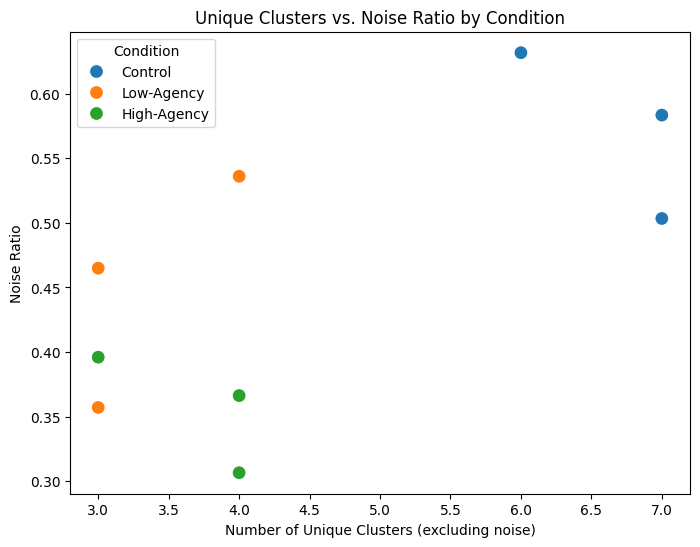


Correlation between Unique Clusters and Noise Ratio: 0.67 (p-value: 0.0462)


In [44]:
# Make a scatterplot with number of unique clusters on the x-axis and noise ratio on the y-axis, colored by condition, for the above data
plt.figure(figsize=(8, 6))
sns.scatterplot(data=results_df, x='Unique_Clusters', y='Noise_Ratio', hue='Condition', palette='tab10', s=100)
plt.title('Unique Clusters vs. Noise Ratio by Condition')
plt.xlabel('Number of Unique Clusters (excluding noise)')
plt.ylabel('Noise Ratio')
plt.legend(title='Condition')
plt.show()

# Check if the correlation between number of unique clusters and noise ratio is significant

corr, p_value = pearsonr(results_df['Unique_Clusters'], results_df['Noise_Ratio'])
print(f"\nCorrelation between Unique Clusters and Noise Ratio: {corr:.2f} (p-value: {p_value:.4f})")

In [31]:
# Read in CloudResearch data for comparison
cloudresearch_path = '~/Git_Projects/idea_generation/data/cloudresearch_ideas.csv'
cloudresearch_df = pd.read_csv(cloudresearch_path)

# Get embeddings for CloudResearch ideas
cloudresearch_ideas = cloudresearch_df['idea_text'].fillna("").tolist()
cloudresearch_ideas = [idea.strip().lower() for idea in cloudresearch_ideas]
cloudresearch_embeddings = model.encode(cloudresearch_ideas, show_progress_bar=True)


Batches: 100%|██████████| 165/165 [00:02<00:00, 68.65it/s] 


In [48]:
# Cluster ideas by condition and object
# Extract object name from trial_id, which should be the only alphabetic part of the trial_id string
cloudresearch_df['object'] = cloudresearch_df['trial_id'].str.extract('([a-zA-Z]+)')[0]

# 4. Prepare for Clustering
unique_cloudresearch_objects = cloudresearch_df['object'].unique()
unique_cloudresearch_conditions = cloudresearch_df['Condition'].unique()

# Use HDBSCAN to cluster ideas based on their embeddings
for cond in unique_cloudresearch_conditions:
    for obj in unique_cloudresearch_objects:
        obj_cond_mask = (cloudresearch_df['object'] == obj) & (cloudresearch_df['Condition'] == cond)
        # Get the 384-dimensional vectors
        raw_vectors = cloudresearch_embeddings[obj_cond_mask]
        
        # HDBSCAN with 'cosine' metric for raw embeddings
        # min_cluster_size: Adjust this based on total N (e.g., 5-10)
        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=15, 
            min_samples=1,
            cluster_selection_epsilon=0.25, # Adjust this to control cluster granularity
            metric='euclidean', # Note: HDBSCAN works best with euclidean on normalized vectors
            cluster_selection_method='eom'
        )
        # Normalize vectors to behave better with cosine distance in HDBSCAN
        normalized_vectors = normalize(raw_vectors)
        
        cluster_labels = clusterer.fit_predict(normalized_vectors)
        
        cloudresearch_df.loc[obj_cond_mask, 'raw_cluster_label'] = cluster_labels

pd.DataFrame(cloudresearch_df)


,participantId,subset_id,trial_id,idea_text,submitter_condition,creative,original,useful,Condition,submitter_id,White,gender,age,object,raw_cluster_label
0,46331EBA4F494FAD901E83106523FF12,37,37_brick_1,gardening edge,high-agency,1,1,3,high-agency,R_7shOmPjoZbDavJ3,0.0,2.0,46.0,brick,-1.0
1,46331EBA4F494FAD901E83106523FF12,37,37_brick_2,raise table,unstructured,1,1,3,unstructured,R_1rRWkqWjMpVjnfX,1.0,2.0,61.0,brick,-1.0
2,46331EBA4F494FAD901E83106523FF12,37,37_brick_3,DIY weight for working out,low-agency,2,2,2,low-agency,R_3LJeKKPsxcxhr3z,1.0,2.0,25.0,brick,4.0
3,46331EBA4F494FAD901E83106523FF12,37,37_brick_4,Paperweight,low-agency,1,1,2,low-agency,R_6CDtTBo8XpFG9jh,0.0,2.0,47.0,brick,5.0
4,46331EBA4F494FAD901E83106523FF12,37,37_brick_5,Door Stop,low-agency,1,1,5,low-agency,R_3tosQzl5ewKGw22,1.0,1.0,71.0,brick,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5260,9696FCC6AC3345178BE1523A37625CB2,230,230_bubblewrap_1,Cushioning for delicate items,unstructured,1,1,5,unstructured,R_39WwXjQHEhZqsQF,1.0,1.0,51.0,bubblewrap,3.0
5261,9696FCC6AC3345178BE1523A37625CB2,230,230_bubblewrap_2,stress reliever,high-agency,2,1,4,high-agency,R_6iJVjz4o575XFNY,0.0,2.0,42.0,bubblewrap,3.0
5262,9696FCC6AC3345178BE1523A37625CB2,230,230_bubblewrap_3,use popping and crinkling bubbles as a sound e...,unstructured,2,2,2,unstructured,R_67D4IcFIfMqLzOn,1.0,2.0,74.0,bubblewrap,-1.0
5263,9696FCC6AC3345178BE1523A37625CB2,230,230_bubblewrap_4,Having a wrapped up battle between 2 people,control,3,3,3,control,R_1VSz9Wi7mxaEQHn,1.0,1.0,52.0,bubblewrap,-1.0


In [25]:
# For each object-condition pair, plot t-SNE for CloudResearch data
# Display in a grid of t-SNE plots for all object-condition pairs
n_objects = len(unique_cloudresearch_objects)
n_conditions = len(unique_cloudresearch_conditions)

# Create a grid of subplots
# Order the conditions as Control, Unstructured, Low-Agency, High-Agency
condition_order = ['unstructured', 'low-agency', 'high-agency', 'control']
# Order the objects as brick, bubblewrap, frisbee
object_order = ['brick', 'bubblewrap', 'frisbee']

unique_cloudresearch_conditions = [cond for cond in condition_order if cond in cloudresearch_df['Condition'].unique()]
unique_cloudresearch_objects = [obj for obj in object_order if obj in cloudresearch_df['object'].unique()]

fig, axes = plt.subplots(n_objects, n_conditions, figsize=(4*n_conditions, 3*n_objects), squeeze=False)
# For each object-condition pair, plot t-SNE
for i, obj in enumerate(unique_cloudresearch_objects):
    for j, condition in enumerate(unique_cloudresearch_conditions):
        obj_cond_mask = (cloudresearch_df['object'] == obj) & (cloudresearch_df['Condition'] == condition)
        if obj_cond_mask.sum() < 2:  # Skip if less than 2 samples
            ax = axes[i][j]
            ax.text(0.5, 0.5, "Not enough samples", ha='center', va='center', transform=ax.transAxes)
            continue

        data = cloudresearch_embeddings[obj_cond_mask]
        projection = sklearn.manifold.TSNE().fit_transform(data)

        # Color the points by their cluster labels to visually inspect the clustering quality
        labels = cloudresearch_df.loc[obj_cond_mask, 'raw_cluster_label'].values
        unique_labels = np.sort(np.unique(labels))

        # Build color map where -1 is light gray using colorblind-friendly palette
        base_colors = sns.color_palette('colorblind', n_colors=max(len(unique_labels), 1))
        color_map = {}
        color_iter = iter(base_colors)

        for lab in unique_labels:
            if lab == -1:
                color_map[lab] = 'lightgray'
            else:
                color_map[lab] = next(color_iter, 'black')

        cmap = mcolors.ListedColormap([color_map[lab] for lab in unique_labels])
        norm = mcolors.BoundaryNorm(np.append(unique_labels, unique_labels[-1] + 1), cmap.N)

        axes[i][j].scatter(projection[:, 0], projection[:, 1], c=labels, cmap=cmap, norm=norm, alpha=0.7)
        
        # Add subplot title with bold condition only, centered
        ax = axes[i][j]
        ax.text(0.5, 1.05, condition, ha='right', va='bottom',
               transform=ax.transAxes, fontsize=16, weight='bold', family='Avenir')
        ax.text(0.5, 1.05, ': ' + obj, ha='left', va='bottom',
               transform=ax.transAxes, fontsize=16, family='Avenir')

        # Add more space between subplots for better readability
        plt.subplots_adjust(wspace=0.3, hspace=0.3)

# Save a high-resolution version of the plot
fig.savefig('figures/tsne_clusters_cloudresearch.png', dpi=300)

plt.tight_layout()
plt.show()


NameError: name 'unique_cloudresearch_objects' is not defined

In [50]:
# For each condition, compute the number of unique clusters 

# for condition in unique_cloudresearch_conditions:
#     condition_mask = (cloudresearch_df['Condition'] == condition)
#     num_clusters = cloudresearch_df[condition_mask & (cloudresearch_df['raw_cluster_label'] != -1)]['raw_cluster_label'].nunique()
#     print(f"Condition: {condition}, Number of Unique Clusters (excluding noise): {num_clusters}")

# # For each condition, compute the noise ratio (proportion of ideas in the noise cluster) for CloudResearch data
# for condition in unique_cloudresearch_conditions:
#     condition_mask = (cloudresearch_df['Condition'] == condition)
#     noise_ratio = (cloudresearch_df[condition_mask]['raw_cluster_label'] == -1).mean()
#     print(f"Condition: {condition}, Noise Ratio: {noise_ratio:.2f}")

# # For each condition, compute the coefficient of variation for cluster counts in CloudResearch data
# for condition in unique_cloudresearch_conditions:
#     condition_mask = (cloudresearch_df['Condition'] == condition)
#     cluster_counts = cloudresearch_df[condition_mask]['raw_cluster_label'].value_counts()
#     # Exclude noise cluster (-1)
#     if -1 in cluster_counts.index:
#         cluster_counts = cluster_counts.drop(-1)
#     if len(cluster_counts) > 1:  # Avoid division by zero
#         cv = cluster_counts.std() / cluster_counts.mean()
#     else:
#         cv = np.nan  # Not enough clusters to calculate CV
#     print(f"Condition: {condition}, Coefficient of Variation for Cluster Counts: {cv:.2f}")

cloudresearch_cluster_stats = []

for condition in unique_cloudresearch_conditions:
    for obj in unique_cloudresearch_objects:
        # Normalize condition names for matching
        obj_cond_mask = (cloudresearch_df['object'] == obj) & (cloudresearch_df['Condition'].str.lower() == condition.lower())
        
        # Get stats
        unique_clusters = cloudresearch_df.loc[obj_cond_mask, 'raw_cluster_label'].nunique() - 1
        noise_ratio = (cloudresearch_df.loc[obj_cond_mask, 'raw_cluster_label'] == -1).mean()
        cluster_counts = cloudresearch_df.loc[obj_cond_mask & (cloudresearch_df['raw_cluster_label'] != -1), 'raw_cluster_label'].value_counts()
        cv = cluster_counts.std() / cluster_counts.mean() if len(cluster_counts) > 1 else np.nan

        cloudresearch_cluster_stats.append({
            'Object': obj,
            'Condition': condition,
            'Unique_Clusters': unique_clusters,
            'Noise_Ratio': noise_ratio,
            'Coefficient_of_Variation': cv
        })

cloudresearch_stats_df = pd.DataFrame(cloudresearch_cluster_stats)
print(cloudresearch_stats_df)

for metric in metrics:
    obs_means, obs_stat, p = permutation_maxmin_pvalue(
        cloudresearch_stats_df, metric=metric, group_col="Condition", n_perm=5000, seed=42
    )
    print(f"\n=== CloudResearch {metric} ===")
    print("Observed condition means:")
    print(obs_means)
    print(f"Observed statistic (max-min): {obs_stat:.4f}")
    print(f"Permutation p-value: {p:.4f}")

        Object     Condition  Unique_Clusters  Noise_Ratio  \
0        brick  unstructured                7     0.551339   
1   bubblewrap  unstructured                8     0.511312   
2      frisbee  unstructured                8     0.395973   
3        brick    low-agency               10     0.286047   
4   bubblewrap    low-agency                8     0.491189   
5      frisbee    low-agency                8     0.380734   
6        brick   high-agency                6     0.603175   
7   bubblewrap   high-agency                4     0.533693   
8      frisbee   high-agency                3     0.538874   
9        brick       control                8     0.312625   
10  bubblewrap       control                8     0.370902   
11     frisbee       control               10     0.418838   

    Coefficient_of_Variation  
0                   0.313249  
1                   0.495324  
2                   1.116277  
3                   0.478740  
4                   0.224775  
5      

/var/folders/lz/6c9r7h8n39zgx1pvrzsj13900000gn/T/ipykernel_1771/835354115.py:24: UserWarning: you are shuffling a 'StringArray' object which is not a subclass of 'Sequence'; `shuffle` is not guaranteed to behave correctly. E.g., non-numpy array/tensor objects with view semantics may contain duplicates after shuffling.
  rng.shuffle(shuffled)



=== CloudResearch Unique_Clusters ===
Observed condition means:
Condition
control         8.666667
high-agency     4.333333
low-agency      8.666667
unstructured    7.666667
Name: Unique_Clusters, dtype: float64
Observed statistic (max-min): 4.3333
Permutation p-value: 0.0352

=== CloudResearch Noise_Ratio ===
Observed condition means:
Condition
control         0.367455
high-agency     0.558580
low-agency      0.385990
unstructured    0.486208
Name: Noise_Ratio, dtype: float64
Observed statistic (max-min): 0.1911
Permutation p-value: 0.0820

=== CloudResearch Coefficient_of_Variation ===
Observed condition means:
Condition
control         0.470081
high-agency     0.700699
low-agency      0.443268
unstructured    0.641617
Name: Coefficient_of_Variation, dtype: float64
Observed statistic (max-min): 0.2574
Permutation p-value: 0.7199


In [55]:
# Examine the points that are in the noise cluster (-1) for CloudResearch data to see if they are qualitatively different from the clustered ideas
noise_ideas = cloudresearch_df[cloudresearch_df['raw_cluster_label'] == -1]
print(f"\nNoise Cluster (-1) for CloudResearch Data:")
print(f"Total Ideas in Noise Cluster: {noise_ideas.shape[0]}")
for example, object in noise_ideas[['idea_text', 'object']].head(10).itertuples(index=False):
    print(f" - {example} (Object: {object})")


Noise Cluster (-1) for CloudResearch Data:
Total Ideas in Noise Cluster: 2335
 - gardening edge (Object: brick)
 - raise table (Object: brick)
 - Use as a cover for outdoor pots/plants or buckets (Object: frisbee)
 - weapon (Object: frisbee)
 - flower pot (Object: brick)
 - wall (Object: brick)
 - Use a wedge between a door to keep it open. (Object: frisbee)
 - paint pallet (Object: frisbee)
 - helmet (Object: bubblewrap)
 - as a blanket (Object: bubblewrap)


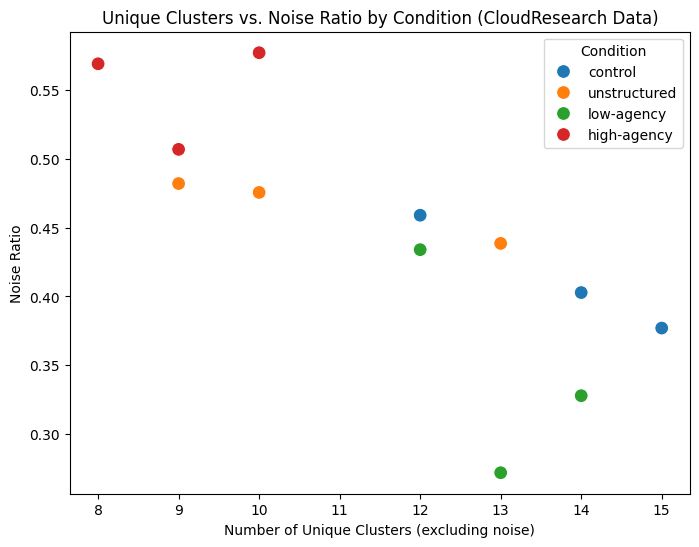


Correlation between Unique Clusters and Noise Ratio (CloudResearch Data): -0.80 (p-value: 0.0019)


In [45]:
# Make a scatterplot with number of unique clusters on the x-axis and noise ratio on the y-axis, colored by condition, for cloudresearch data
plt.figure(figsize=(8, 6))
sns.scatterplot(data=cloudresearch_stats_df, x='Unique_Clusters', y='Noise_Ratio', hue='Condition', palette='tab10', s=100)
plt.title('Unique Clusters vs. Noise Ratio by Condition (CloudResearch Data)')
plt.xlabel('Number of Unique Clusters (excluding noise)')
plt.ylabel('Noise Ratio')
plt.legend(title='Condition')
plt.show()

# Check if the correlation between number of unique clusters and noise ratio is significant for CloudResearch data
corr, p_value = pearsonr(cloudresearch_stats_df['Unique_Clusters'], cloudresearch_stats_df['Noise_Ratio'])
print(f"\nCorrelation between Unique Clusters and Noise Ratio (CloudResearch Data): {corr:.2f} (p-value: {p_value:.4f})")

In [357]:
# Display example ideas from a specific object-condition pair in CloudResearch data (e.g., bubblewrap in Low-Agency)
obj = "brick"
condition = "control"

obj_cond_mask = (cloudresearch_df['object'] == obj) & (cloudresearch_df['Condition'] == condition)
clustered_ideas = cloudresearch_df.loc[obj_cond_mask & (cloudresearch_df['raw_cluster_label'] != -1), ['idea_text', 'raw_cluster_label']]
# Display example ideas from each cluster and print the total number of ideas in each cluster
# Arrange in order of cluster size
for cluster_label in clustered_ideas['raw_cluster_label'].value_counts().index:
    print(f"\nCluster {cluster_label}:")
    print(f"Total Ideas in Cluster: {(clustered_ideas['raw_cluster_label'] == cluster_label).sum()}")
    examples = clustered_ideas[clustered_ideas['raw_cluster_label'] == cluster_label]['idea_text'].head(10).tolist()
    for example in examples:
        print(f" - {example}")


Cluster 3.0:
Total Ideas in Cluster: 42
 - pet brick
 - You can use it as support for a structure.
 - to build a fireplace
 - firepit
 - House construction
 - chimney
 - build a firepit
 - structure design
 - Building
 - Fire pits

Cluster 11.0:
Total Ideas in Cluster: 34
 - Art medium
 - painted decoration
 - artistically paint designs on it and give away for gifts
 - Decorative
 - canvas
 - Painting
 - decoration
 - ceremonial decoration
 - decorative art
 - paited for artwork

Cluster 7.0:
Total Ideas in Cluster: 31
 - use as a doorstop
 - Makeshift doorstop.
 - As a doorstop
 - doorstop
 - Doorstopper
 - Doorstop
 - Bookend or doorstop
 - as a doorstop
 - doorstop
 - a doorstop

Cluster 8.0:
Total Ideas in Cluster: 30
 - door stop
 - door stop
 - Hold open a door
 - door stop
 - door stop
 - door stop
 - as a door stopper
 - door stop
 - door stop
 - door stop

Cluster 0.0:
Total Ideas in Cluster: 30
 - paper weight
 - paperweight
 - paperweight
 - paperweight
 - paper wieght
 - A